In [ ]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [1]:
from stericheight.utils import *
from stericheight.data_handler import *
from stericheight.plotting_fns import *
from stericheight.steric_height import *

pf = PlottingFns()

In [2]:
import cartopy.crs as ccrs
import xarray as xr
import cmocean
import matplotlib.patches as mpatches

In [3]:
# helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

In [4]:
lwe_ds = GRACE().ds
sla_ds = SLA().ds
dot_ds = DOT().ds
elevation = GEBCO().ds.elevation

/nfs/b0133/eejco/miniconda3/envs/sha-env/lib/python3.10/site-packages/xarray/core/nputils.py:248: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


In [5]:
sha_ds_sla = StericHeight(ssh_ref='SLA',
                      ssh=sla_ds.sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

Interpolating to curvilinear DOT grid


In [6]:
extent = [112,118,-67,-65]

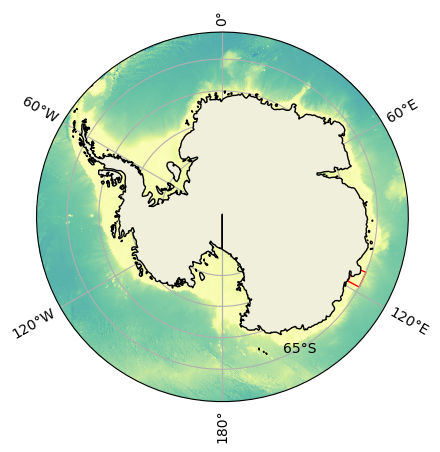

In [7]:
fig, ax = plt.subplots(subplot_kw={"projection":ccrs.SouthPolarStereo()})
pf.sp(ax,elevation,sea='Small Southern Ocean')
ax.add_patch(mpatches.Rectangle(xy=[extent[0], extent[2]],
                                width=extent[1]-extent[0],
                                height=extent[3]-extent[2],
                                facecolor='none', edgecolor='r',
                                transform=ccrs.PlateCarree()))

In [8]:
# crop datasets to chosen area
sla = crop_to_extent(sla_ds,extent).sla
lwe = crop_to_extent(lwe_ds,extent).lwe_thickness
dot = crop_to_extent(dot_ds,extent).dot
sha_dot = crop_to_extent(sha_ds_dot,extent).sha
sha_sla = crop_to_extent(sha_ds_sla,extent).sha


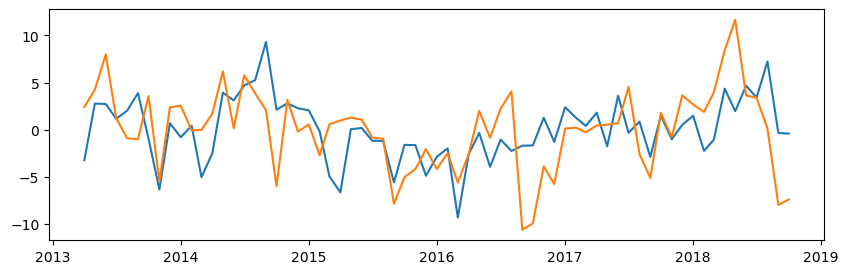

In [9]:
start = sla.time[0]
end = dot.time[-1]

sla_cropped = sla.sel(time=slice(start,end))
sla_adjusted = sla_cropped - sla_cropped.mean('time')

dot_cropped = dot.sel(time=slice(start,end))
dot_adjusted = dot_cropped - dot_cropped.mean('time')

fig,ax = plt.subplots(figsize=(10,3))
ax.plot(dot_adjusted.time, dot_adjusted.mean(['latitude','longitude']))
ax.plot(sla_adjusted.time, sla_adjusted.mean(['x','y']))

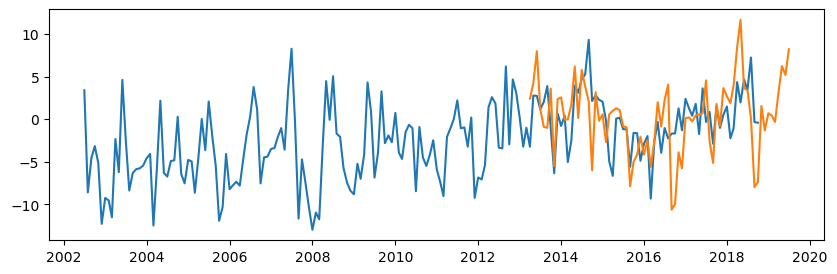

In [10]:
sla_adjusted_full = sla - sla_cropped.mean('time')
dot_adjusted_full = dot - dot_cropped.mean('time')

fig,ax = plt.subplots(figsize=(10,3))
ax.plot(dot_adjusted_full.time, dot_adjusted_full.mean(['latitude','longitude']))
ax.plot(sla_adjusted_full.time, sla_adjusted_full.mean(['x','y']))